# Axe 1 : Vie personnelle 

Dans ce notebook, j'étudie les variables liées aux caractéristiques personnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l’axe
- de visualiser
- retenir seulement ce qui ressort clairement
---

## 1. Exploration des variables de l’axe
---

### 1.1 Import des librairies & chargement des données
---

In [3]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.info()

### 1.2 Creation du DataFrame vie_perso
---
#### Colonnes incluses dans l'axe "Vie personnelle"

Cet axe regroupe les caractéristiques individuelles :
- âge  
- situation familiale  
- genre  
- niveau d'éducation  et domaines
- mobilité géographique  
donnant un contexte personnel pouvant influencer l'attrition.

In [ ]:
# colonnes vie_perso
col_perso = ['Age', 'DistanceFromHome','Education','EducationField','Gender','MaritalStatus','NumCompaniesWorked']

# creation df_vie_perso
df_vie_perso = df_clean[col_perso + ['Attrition']].copy()
df_vie_perso.head()

#### 1.2.1 Création des tranches d’âge

L'âge est une variable continue peu lisible en l'état.  
Pour faciliter l'analyse et observer des tendances plus nettes, je regroupe les employés en classes d'âge cohérentes du point de vue RH :

- **18–25 ans** : début de carrière, forte mobilité
- **26–35 ans** : stabilisation professionnelle, construction familiale
- **36–45 ans** : maturité professionnelle
- **46–55 ans** : employés expérimentés
- **55+ ans** : fin de carrière

Ces tranches permettront d'étudier plus clairement la relation entre âge et attrition.

In [ ]:
# Creation tranche d'age
df_vie_perso["Tranche_Age"] = pd.cut(
    df_vie_perso["Age"],
    bins=[0 , 25, 35, 45, 55, 150],
    labels=["18-25", "26-35", "36-45", "46-55", "+55"],
    ordered=True,
    include_lowest=True
)

df_vie_perso["Tranche_Age"].value_counts()

#### 1.2.2 Regroupement distance domicile–travail

Pour faciliter l'analyse exploratoire et rendre les visualisations plus lisibles, la distance est regroupée en tranches cohérentes :

- **1–5 km** : très proche  
- **6–10 km** : proche  
- **11–20 km** : distance moyenne  
- **> 20 km** : éloigné  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre la distance domicile–travail et l’attrition.


In [8]:
# Creation des regroupement

df_vie_perso['Tranche_Distance'] = pd.cut(
    df_vie_perso['DistanceFromHome'],
    bins = [0, 5, 10, 20, 30],
    labels= ["1-5", "6-10", "11-20", ">20"],
    include_lowest=True,
    ordered=True
)

df_vie_perso["Tranche_Distance"].value_counts()

Tranche_Distance
1-5      632
6-10     394
11-20    240
>20      204
Name: count, dtype: int64

#### 1.2.3 Renommage des niveaux d’éducation

Les niveaux d’éducation sont initialement codés sous forme numérique (1 à 4).Pour faciliter la lecture et l’analyse, je remplace ces codes par des catégories explicites 
Cette transformation permet d’interpréter facilement la répartition des employés selon leur niveau d’étude.


In [9]:
niveau_education = {
    1 : 'Below College',
    2 : 'College',
    3 : 'Bachelor',
    4 : 'Master',
    5 : 'Doctor'
    }

df_vie_perso["NiveauEducation"] = df_vie_perso['Education'].replace(niveau_education)
df_vie_perso.head()

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Attrition,Tranche_Age,Tranche_Distance,NiveauEducation
0,41,1,2,Life Sciences,Female,Single,8,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Male,Married,1,No,46-55,6-10,Below College
2,37,2,2,Other,Male,Single,6,Yes,36-45,1-5,College
3,33,3,4,Life Sciences,Female,Married,1,No,26-35,1-5,Master
4,27,2,1,Medical,Male,Married,9,No,26-35,1-5,Below College


#### 1.2.4 Renommage des genres
La variable `Gender` utilise des codes bruts (`Male`, `Female`).  
Je les remplace par des libellés plus explicites (*Homme* et *Femme*) afin d'améliorer la lisibilité et la cohérence du jeu de données.

In [10]:
df_vie_perso["Gender"] = df_vie_perso["Gender"].replace({
    "Male": "Homme",
    "Female": "Femme"
})
df_vie_perso.head()

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Attrition,Tranche_Age,Tranche_Distance,NiveauEducation
0,41,1,2,Life Sciences,Femme,Single,8,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Homme,Married,1,No,46-55,6-10,Below College
2,37,2,2,Other,Homme,Single,6,Yes,36-45,1-5,College
3,33,3,4,Life Sciences,Femme,Married,1,No,26-35,1-5,Master
4,27,2,1,Medical,Homme,Married,9,No,26-35,1-5,Below College


#### 1.2.5 Regroupement du nombre d’entreprises précédemment travaillées

Pour faciliter l’analyse exploratoire et rendre les visualisations plus lisibles, le nombre d’entreprises précédemment travaillées est regroupé en tranches cohérentes :

- **0–1 entreprise** : employés très stables ou débutants  
- **2–3 entreprises** : employés ayant une mobilité modérée  
- **4–6 entreprises** : employés ayant une mobilité élevée  
- **7+ entreprises** : employés ayant une forte instabilité ou une carrière très variée  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre le nombre d’entreprises précédemment travaillées et l’attrition.


In [11]:
df_vie_perso['Tranche_EtsTravaille'] = pd.cut(
    df_vie_perso['NumCompaniesWorked'],
    bins= [0, 1, 3, 6, 10],
    labels= ["0-1", "2-3", "4-6", "+7"],
    ordered=True,
    include_lowest=True
)

df_vie_perso["Tranche_EtsTravaille"].value_counts()

Tranche_EtsTravaille
0-1    718
2-3    305
4-6    272
+7     175
Name: count, dtype: int64

### 1.3  Analyse individuelle des variables 
---
Dans cette section, j’analyse plusieurs caractéristiques personnelles des employés afin de mieux comprendre la composition de la population étudiée.  
Les variables sont analysées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.


#### 1.3.1 Tranche d’âge 
---
Je trie les tranches d’âge selon leur fréquence afin d’identifier rapidement les groupes les plus représentés au sein de l’entreprise et préparer l’analyse exploratoire.


##### Tableau des proportions

In [10]:

age = df_vie_perso["Tranche_Age"].value_counts(normalize=True).sort_values(ascending=False)*100

df_age = age.reset_index()
df_age.columns = ["Tranche_Age" , 'Pourcentage']
df_age

,Tranche_Age,Pourcentage
0,26-35,41.224490
1,36-45,31.836735
2,46-55,15.374150
3,18-25,8.367347
4,+55,3.197279


##### Histogramme des tranches d'âge

Ce graphique montre la répartition des employés selon les tranches d'âge.  
On observe deux groupes majoritaires :

- **26–35 ans**  
- **36–45 ans**

Ils représentent la majorité de la population active de l’entreprise.

Les tranches :

- **18–25 ans** et **46–55 ans** sont moins représentées,  
- tandis que les **55+** sont très minoritaires.


In [ ]:


plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines["right"].set_visible(False)

sns.barplot(data=df_age,y="Pourcentage", x="Tranche_Age",color="skyblue")
plt.xlabel("Tranche d'Age")
plt.ylabel("Pourcentage")
plt.title("Répartition des employéess par tranche d'age (en %)")
plt.tight_layout()
plt.show(),

Après avoir examiné la répartition par âge, je m’intéresse maintenant à la proximité des employés avec leur lieu de travail à travers la variable `DistanceFromHome`.

#### 1.3.2 DistanceFromHome
---
J’analyse ici la répartition des employés selon la distance entre leur domicile et le lieu de travail, afin d’identifier les niveaux de proximité les plus fréquents dans l’entreprise.


##### Tableau des proportions

In [9]:

distanceFromHome = df_vie_perso["Tranche_Distance"].value_counts(normalize=True).sort_values(ascending=False)*100

df_distanceFromHome = distanceFromHome.reset_index()
df_distanceFromHome.columns = ["Tranche_Distance", "Pourcentage"]

df_distanceFromHome

,Tranche_Distance,Pourcentage
0,1-5,42.993197
1,6-10,26.802721
2,11-20,16.326531
3,>20,13.877551


#### 

#### Répartition des employés par distance domicile–travail
On observe que les employés habitant très près ou relativement proches de leur lieu de travail représentent la majorité de l’effectif, 
avec près de 70 % situés à moins de 10 km.  
À l’inverse, les personnes résidant à plus de 20 km restent minoritaires (≈14 %).



In [ ]:


plt.figure(figsize=(7,5))

sns.barplot(data=df_distanceFromHome, y="Tranche_Distance",x="Pourcentage",color="skyblue")

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

plt.xlabel("Pourcentage (%)")
plt.ylabel("Tranche des Distances")
plt.title("Répartition des employés par distance domicile–travail (en %)")
plt.tight_layout()
plt.show(),

Une fois la distance domicile–travail analysée, j’explore maintenant la répartition des niveaux d’éducation au sein de l’entreprise.

#### 1.3.3 Niveau d’éducation
---
J’analyse ici la répartition des employés selon leur niveau d’éducation. Les niveaux codés dans le jeu de données sont convertis en catégories explicites afin de faciliter la lecture et l’interprétation.



##### Tableau des proportions

In [11]:

education = df_vie_perso['NiveauEducation'].value_counts(normalize=True).sort_values(ascending=False)*100

df_education = education.reset_index()
df_education.columns = ["Niveau d'Education", "Pourcentage"]

df_education

,Niveau d'Education,Pourcentage
0,Bachelor,38.911565
1,Master,27.074830
2,College,19.183673
3,Below College,11.564626
4,Doctor,3.265306


##### Répartition des employés par niveau d'education

On observe qu’un peu plus de la moitié des employés ont un niveau Bachelor (≈39 %) ou Master (≈27 %).  
Environ 30 % présentent un niveau College ou Below College, tandis qu’une minorité (≈3 %) ont atteint le niveau Doctorat.

In [ ]:

plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_education, y="Niveau d'Education", x= "Pourcentage", color='skyblue')
plt.xlabel("Pourcentage")
plt.ylabel("Niveau d'Education")
plt.title("Répartition des employés par niveau d'education (en %)")
plt.tight_layout()
plt.show(),

Après avoir exploré le niveau d’éducation des employés, j’analyse maintenant leur domaine d’étude à travers la variable `EducationField`.

#### 1.3.4 Domaine d’éducation (EducationField)
---

J’analyse ici la répartition des employés selon leur domaine d’éducation (`EducationField`).  
Cette variable permet d’identifier les disciplines académiques les plus représentées dans l’entreprise et d’observer la diversité des parcours.


##### Tableau des proportions

In [12]:
educationField = df_vie_perso["EducationField"].value_counts(normalize=True).sort_values(ascending=False)*100

df_EducationField = educationField.reset_index()
df_EducationField.columns =['Education Field', "Pourcentage"]

df_EducationField

,Education Field,Pourcentage
0,Life Sciences,41.22449
1,Medical,31.564626
2,Marketing,10.816327
3,Technical Degree,8.979592
4,Other,5.578231
5,Human Resources,1.836735


##### Repartitions des employes par domaine d'education

CCe graphique montre que deux domaines d’éducation sont particulièrement représentés :  
- **Life Sciences** (≈ 41 %)  
- **Medical** (≈ 32 %)  

Les domaines minoritaires sont **Other** (≈ 5 %) et **Human Resources** (≈ 2 %).

Cette exploration permet d’avoir une première vision des types de parcours académiques présents dans l’entreprise et d’apprécier la diversité des profils.

In [ ]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_EducationField, y= "Education Field", x= "Pourcentage", color="skyblue")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Education Field")
plt.title("Répartition des employés par domaine d’éducation (en %)")
plt.tight_layout()
plt.show(),

Après l’analyse des domaines d’éducation, j’explore maintenant la répartition des employés selon leur genre.

#### 1.3.5 Genre
---
J’analyse ici la répartition des employés selon leur genre.  
Cette variable permet d’observer la composition de la population en termes de diversité et d’équilibre hommes–femmes.

##### Tableau des proportions

In [13]:
# Repartition par genre

genre = df_vie_perso["Gender"].value_counts(normalize=True).sort_values(ascending=False)*100
df_genre = genre.reset_index()

df_genre.columns = ["Genre", "Pourcentage"]
df_genre.reset_index()

df_genre

,Genre,Pourcentage
0,Homme,60.0
1,Femme,40.0


##### Repartition des employees par genre

La répartition hommes–femmes est relativement équilibrée dans l’entreprise, avec une légère majorité d'hommes représentant 60 % de l’effectif.


In [ ]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines["top"].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_genre, y= 'Genre', x= "Pourcentage", color="skyblue")
plt.xlabel("Pourcentage")
plt.ylabel('Genre')
plt.title("Repartition des employees par genre (en %)")
plt.tight_layout()
plt.show(),

#### 

Après avoir examiné la répartition par genre, je m’intéresse maintenant au statut marital des employés à travers la variable `MaritalStatus`.

#### 1.3.6 Statut marital
---

J’analyse ici la répartition des employés selon leur statut marital, afin d’identifier les situations familiales les plus représentées dans l’entreprise.


##### Tableau des proportions

In [14]:
maritalStatus = df_vie_perso['MaritalStatus'].value_counts(normalize=True).sort_values(ascending=False)*100

df_MaritalStatus = maritalStatus.reset_index()
df_MaritalStatus.columns = ["Statut marital", "Pourcentage"]

df_MaritalStatus

,Statut marital,Pourcentage
0,Married,45.782313
1,Single,31.972789
2,Divorced,22.244898


##### Repartitions des employees selon leur statut marital

Ce graphique montre que le statut marital le plus représenté est **Married** (≈ 46 %).  
Le statut **Single** concerne environ 32 % des employés, tandis que **Divorced** représente près de 22 %.

Cette exploration permet d’obtenir une première vision des situations familiales présentes dans l’entreprise.

In [ ]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_MaritalStatus, y="Pourcentage", x="Statut marital", color="skyblue")
plt.xlabel("Statut marital")
plt.ylabel("Pourcentage")
plt.title("Repartitions des employees selon leur statut marital (%)")
plt.tight_layout()
plt.show(),

Une fois le statut marital analysé, j’explore maintenant la répartition du nombre d’entreprises dans lesquelles les employés ont travaillé auparavant.

#### 1.3.7 Répartition des employés selon le nombre d’entreprises précédemment travaillées

---
J’analyse ici la répartition des employés selon leur mobilité professionnelle passée.  
Cette variable permet d’observer le niveau de stabilité professionnelle des employés.

##### Tableau des proportions

In [15]:
numCompaniesWorked = df_vie_perso["Tranche_EtsTravaille"].value_counts(normalize=True).sort_values(ascending=False)*100

df_NumCompaniesWorked =numCompaniesWorked.reset_index()
df_NumCompaniesWorked.columns = ["Tranche_NbEntreprises", "Pourcentage"]

df_NumCompaniesWorked

,Tranche_NbEntreprises,Pourcentage
0,0-1,48.843537
1,2-3,20.748299
2,4-6,18.503401
3,+7,11.904762


##### Repartition des employes par le nombre d'entreprise travaillés précédemment

On observe que les employés présentant une mobilité professionnelle faible à modérée représentent la majorité de l’effectif, 
avec près de 65 % des employés ayant travaillé dans au plus trois entreprises.  

À l’inverse, les profils présentant une forte instabilité ou une carrière très variée restent minoritaires (≈14 %).

In [ ]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_NumCompaniesWorked, x="Pourcentage", y="Tranche_NbEntreprises", color="skyblue")
plt.ylabel("Tranche du nombre d'Entreprises")
plt.xlabel("Pourcentage")
plt.title("Répartition des employés par le nombre d’entreprises précédemment travaillées (%)")
plt.tight_layout()
plt.show(),

Cette analyse individuelle permet de mieux comprendre la composition de la population étudiée selon les caractéristiques personnelles.  
La section suivante s’intéresse désormais aux relations entre ces variables et l’attrition.

## 2. Attrition — Comparaisons simples
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables personnelles analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.


##### Tableau de proportions Attrition Yes / No

In [ ]:
attrition = df_vie_perso['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables personnelles
---
Les variables sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de comportement entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et tranche d’âge
---
Dans cette section, je compare l’attrition selon les tranches d’âge afin d’observer si le taux d’attrition varie en fonction de l’âge des employés.


##### Tableau de proportions


In [21]:
# Attrition par tranche d'age
df_age_attrition = df_vie_perso[["Tranche_Age","Attrition"]]
df_age_attrition = df_age_attrition.reset_index(drop=True)
df_age_attrition.head()

# Calcul groupe

age_attrition = df_age_attrition.groupby("Tranche_Age")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(2)*100
age_attrition = age_attrition.reset_index(name="Pourcentage")

display(age_attrition)

# Création d'une table pivot: lignes = Tranche_Age, colonnes = Attrition, valeur = Pourcentage
pivot_age_attrition = age_attrition.pivot(index="Tranche_Age",columns="Attrition", values="Pourcentage").fillna(0)
pivot_age_attrition



C:\Users\Kemu\AppData\Local\Temp\ipykernel_8176\3254526079.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df_age_attrition.groupby("Tranche_Age")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(2)*100


,Tranche_Age,Attrition,Pourcentage
0,36-45,No,91.0
1,46-55,No,88.0
2,+55,No,83.0
3,26-35,No,81.0
4,18-25,No,64.0
5,18-25,Yes,36.0
6,26-35,Yes,19.0
7,+55,Yes,17.0
8,46-55,Yes,12.0
9,36-45,Yes,9.0


Attrition,No,Yes
Tranche_Age,,
18-25,64.0,36.0
26-35,81.0,19.0
36-45,91.0,9.0
46-55,88.0,12.0
+55,83.0,17.0


##### Graphique — Analyse de la relation entre la tranche d’âge et l’attrition

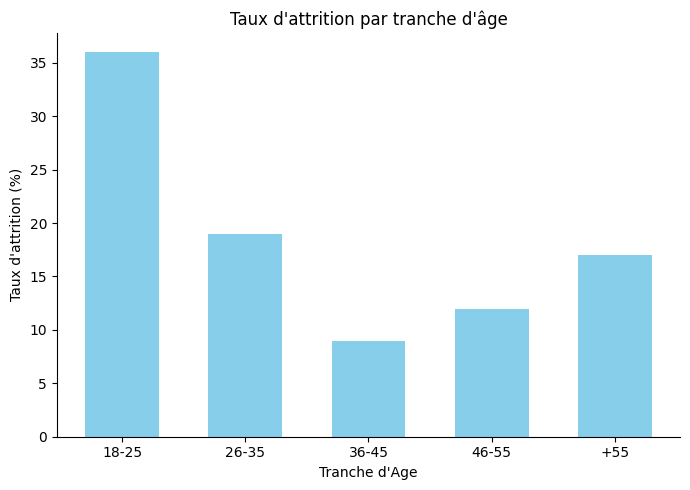

In [22]:

plt.figure(figsize=(7,5))

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(pivot_age_attrition.index))
y = pivot_age_attrition["Yes"]

# barplot
plt.bar(x, y, color="skyblue", width=0.6)

# axes et labels
plt.xticks(x, pivot_age_attrition.index)
plt.xlabel("Tranche d'Age")
plt.ylabel("Taux d'attrition (%)")
plt.title("Taux d'attrition par tranche d'âge")

plt.tight_layout()
plt.show()

##### Observation descriptive

On observe que le taux d’attrition varie selon l’âge.  
La tranche **18–25 ans** présente le taux d’attrition le plus élevé (≈36 %).  
À l’inverse, les tranches **36–45 ans** et **46–55 ans** affichent les taux les plus faibles (≈9 % et ≈12 %).  
Les tranches **26–35 ans** et **+55 ans** se situent à un niveau intermédiaire (≈19 % et ≈17 %).


Après avoir analysé la relation entre l’attrition et les tranches d’âge, je m’intéresse maintenant à une autre variable personnelle : la distance entre le domicile et le lieu de travail.

#### 2.2.2 Attrition et distance domicile–travail
---
Dans cette section, je compare l’attrition selon la distance entre le domicile et le lieu de travail afin d’observer si le taux d’attrition varie en fonction de l’éloignement.

##### Tableau de proportions

In [ ]:
df_distance_attrition = df_vie_perso[["Tranche_Distance","Attrition"]]
df_distance_attrition.reset_index()
df_distance_attrition.head()

# Calcul du groupe
distance_attrition = df_distance_attrition.groupby("Tranche_Distance")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
distance_attrition = distance_attrition.reset_index(name="Pourcentage")
display(distance_attrition)

# Création d'une table pivot: lignes = Tranche_Distance, colonnes = Attrition, valeur = Pourcentage
pivot_distance_attrition = distance_attrition.pivot(index="Tranche_Distance", columns="Attrition", values="Pourcentage").fillna(0)
pivot_distance_attrition

##### Graphique — Analyse de la relation entre la distance domicile–travail et l’attrition

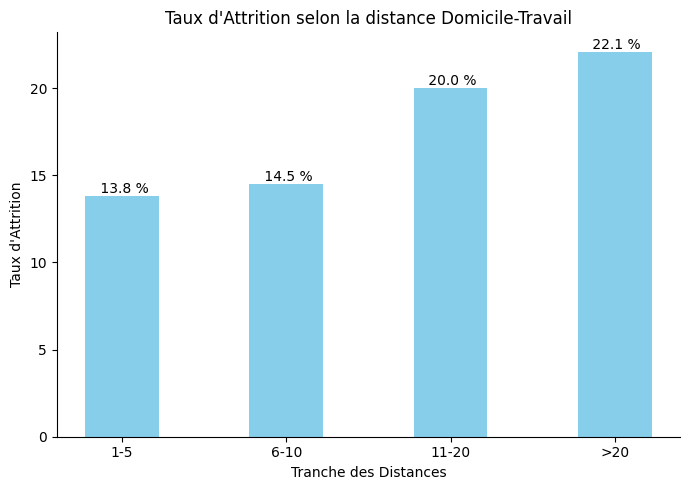

(None,)

In [42]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Donnée
x = np.arange(len(pivot_distance_attrition.index))
y = pivot_distance_attrition['Yes']

# Barplot

bars = ax.bar(x, y, color="Skyblue", width=0.45)

ax.bar_label(bars, labels=[f'{v : .1F} %'for v in y])
ax.set_xticks(x)
ax.set_xticklabels(pivot_distance_attrition.index)
ax.set_xlabel("Tranche des Distances")
ax.set_ylabel("Taux d'Attrition")
ax.set_title("Taux d'Attrition selon la distance Domicile-Travail")
fig.tight_layout()
plt.show(),

On observe que le taux d’attrition est plus faible pour les employés habitant à moins de 10 km de leur lieu de travail, avec un taux compris entre **13 % et 15 %**.  

À l’inverse, le taux d’attrition augmente pour les distances plus élevées : il atteint environ **20 %** pour la tranche **11–20 km** et dépasse **22 %** pour les employés résidant à plus de 20 km.


#### 2.2.3 Attrition et niveau d’éducation
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre le niveau d’éducation et l’attrition

#### 2.2.4 Attrition et domaine d’éducation
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre le domaine d’éducation et l’attrition

#### 2.2.5 Attrition et genre
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre le genre et l’attrition

#### 2.2.6 Attrition et statut marital
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre le statut marital et l’attrition

#### 2.2.7 Attrition et mobilité professionnelle
---

##### Tableau de proportions

##### Graphique — Analyse de la relation entre la mobilité professionnelle et l’attrition

Une fois les comparaisons simples réalisées, j’explore les relations internes à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Relations internes à l’axe 
----
### croisements, graphiques, premières observations

# 4. Visualisations complémentaires
---

# 5. Résultats clés (3 à 5 observations max)
---
ce que J4 observes

sans aller jusqu’à une conclusion business trop poussée